# Análisis de evasión de clientes (Churn)

Este proyecto analiza los datos de Telecom X para identificar patrones asociados con la cancelación del servicio.

#Importar librerías

In [7]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

#Cargar datos

In [8]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)

data = response.json()

df = pd.json_normalize(data)

df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#Explorar datos

In [9]:
print("\nInformación del dataset:")
print(df.info())

print("\nTipos de datos de las columnas:")
print(df.dtypes)

print("\nColumnas del dataset:")
print(df.columns)

print("\nPrimeras filas del dataset:")
print(df.head())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport  

#Verificación de calidad de datos

In [11]:
print("\nValores nulos:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())

print("\nValores únicos en Churn:")
print(df["Churn"].unique())

print("\nValores únicos en gender:")
print(df["customer.gender"].unique())

print("\nValores únicos en tipo de contrato:")
print(df["account.Contract"].unique())


Valores nulos:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Duplicados:
0

Valores únicos en Churn:
['No' 'Yes' '']

Valores únicos en gender:
['Female' 'Male']

Valores únicos en tipo de contrato:
['One year' 'Month-to-month' 'Two year']


#Limpieza

In [12]:
df["Churn"] = df["Churn"].str.lower()
df["Churn"] = df["Churn"].str.strip()

df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

print("\nValores únicos en Churn después de limpieza:")
print(df["Churn"].unique())

print("\nValores nulos después de limpieza:")
print(df.isnull().sum())


Valores únicos en Churn después de limpieza:
['no' 'yes' '']

Valores nulos después de limpieza:
customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64


#Crear variable

In [13]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

print("\nCálculo de cuentas diarias:")
print(df[["account.Charges.Monthly", "Cuentas_Diarias"]].head())


Cálculo de cuentas diarias:
   account.Charges.Monthly  Cuentas_Diarias
0                     65.6         2.186667
1                     59.9         1.996667
2                     73.9         2.463333
3                     98.0         3.266667
4                     83.9         2.796667


#Transformación de datos

In [14]:
df["Churn_binario"] = df["Churn"].replace({
    "yes": 1,
    "no": 0
})

df = df.rename(columns={
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "Adulto_Mayor",
    "account.Contract": "Tipo_Contrato",
    "account.Charges.Monthly": "Cargo_Mensual",
    "account.Charges.Total": "Cargo_Total"
})

print("\nColumnas actualizadas:")
print(df.columns)


Columnas actualizadas:
Index(['customerID', 'Churn', 'Genero', 'Adulto_Mayor', 'customer.Partner',
       'customer.Dependents', 'customer.tenure', 'phone.PhoneService',
       'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato',
       'account.PaperlessBilling', 'account.PaymentMethod', 'Cargo_Mensual',
       'Cargo_Total', 'Cuentas_Diarias', 'Churn_binario'],
      dtype='object')


#Estadisticas descriptivas

In [15]:
print("\nEstadísticas descriptivas del dataset:")
print(df.describe())

print("\nEstadísticas de variables clave:")
print(df[["customer.tenure","Cargo_Mensual","Cargo_Total","Cuentas_Diarias"]].describe())

print("\nDistribución de Churn:")
print(df["Churn"].value_counts())


Estadísticas descriptivas del dataset:
       Adulto_Mayor  customer.tenure  Cargo_Mensual  Cargo_Total  \
count   7267.000000      7267.000000    7267.000000  7256.000000   
mean       0.162653        32.346498      64.720098  2280.634213   
std        0.369074        24.571773      30.129572  2268.632997   
min        0.000000         0.000000      18.250000    18.800000   
25%        0.000000         9.000000      35.425000   400.225000   
50%        0.000000        29.000000      70.300000  1391.000000   
75%        0.000000        55.000000      89.875000  3785.300000   
max        1.000000        72.000000     118.750000  8684.800000   

       Cuentas_Diarias  
count      7267.000000  
mean          2.157337  
std           1.004319  
min           0.608333  
25%           1.180833  
50%           2.343333  
75%           2.995833  
max           3.958333  

Estadísticas de variables clave:
       customer.tenure  Cargo_Mensual  Cargo_Total  Cuentas_Diarias
count      7267.0000

#Distribución de churn


Distribución de churn:
Churn
no     5174
yes    1869
        224
Name: count, dtype: int64


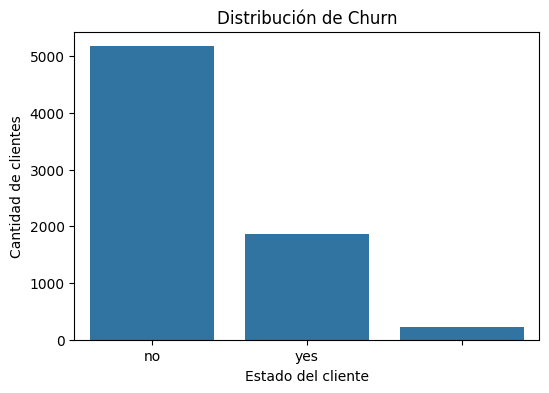

In [16]:
print("\nDistribución de churn:")
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Distribución de Churn")
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")

plt.show()

#Proporción de churn

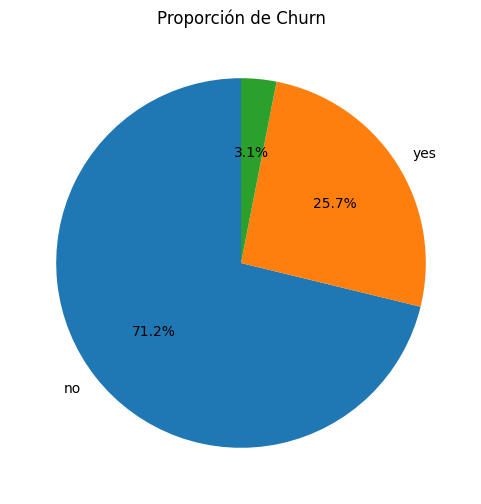

In [17]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Proporción de Churn")

plt.show()

#Churn vs variables categóricas

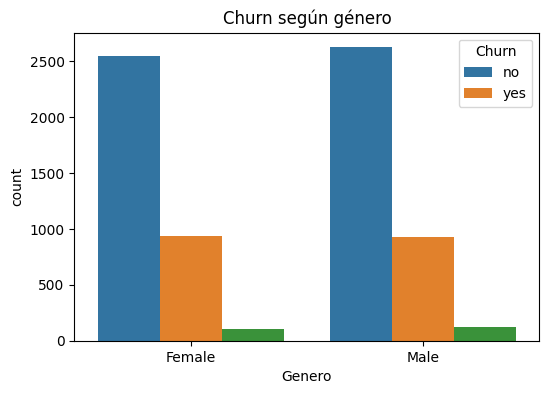

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Genero", hue="Churn", data=df)

plt.title("Churn según género")

plt.show()

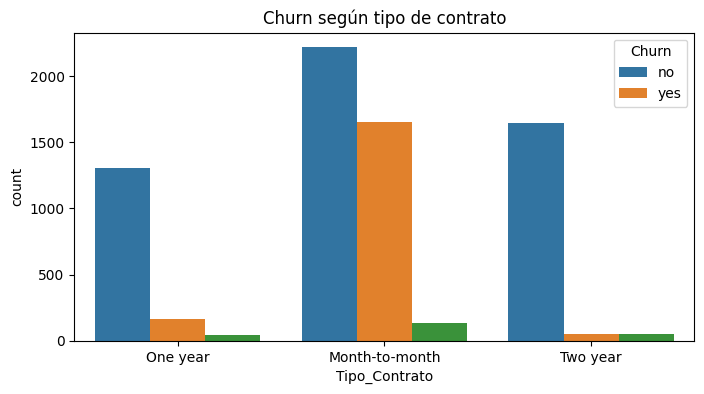

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(x="Tipo_Contrato", hue="Churn", data=df)

plt.title("Churn según tipo de contrato")

plt.show()

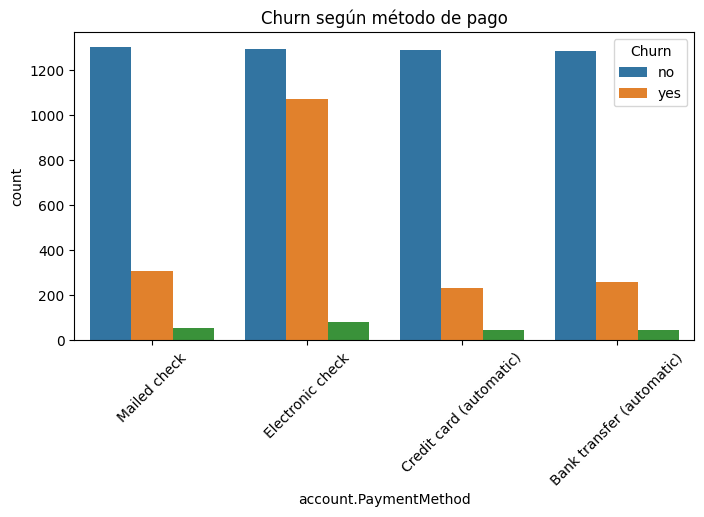

In [20]:
plt.figure(figsize=(8,4))
sns.countplot(x="account.PaymentMethod", hue="Churn", data=df)

plt.title("Churn según método de pago")

plt.xticks(rotation=45)

plt.show()

#Tabla de proporciones

In [21]:
print("\nProporción de churn por tipo de contrato:")

print(pd.crosstab(df["Tipo_Contrato"], df["Churn"], normalize="index"))


Proporción de churn por tipo de contrato:
Churn                           no       yes
Tipo_Contrato                               
Month-to-month  0.032459  0.554307  0.413233
One year        0.030283  0.860434  0.109282
Two year        0.027539  0.944923  0.027539


#Churn vs variables numéricas

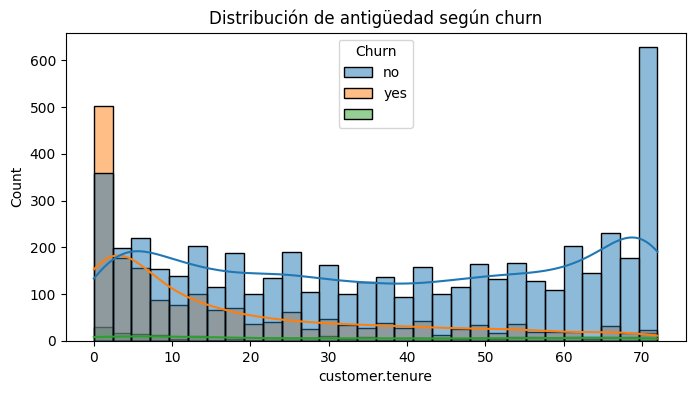

In [22]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x="customer.tenure", hue="Churn", bins=30, kde=True)

plt.title("Distribución de antigüedad según churn")

plt.show()

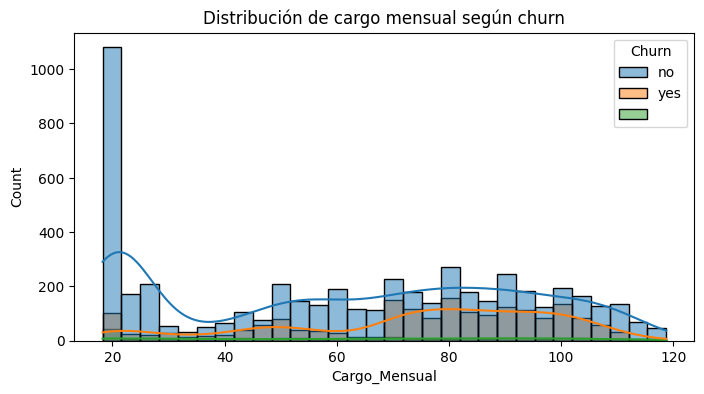

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x="Cargo_Mensual", hue="Churn", bins=30, kde=True)

plt.title("Distribución de cargo mensual según churn")

plt.show()

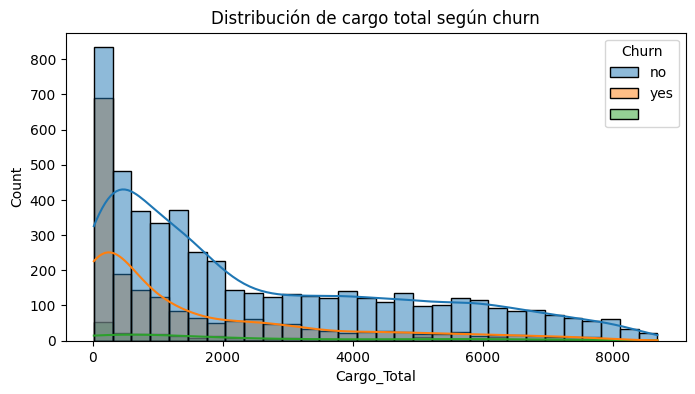

In [24]:
plt.figure(figsize=(8,4))

sns.histplot(data=df, x="Cargo_Total", hue="Churn", bins=30, kde=True)

plt.title("Distribución de cargo total según churn")

plt.show()

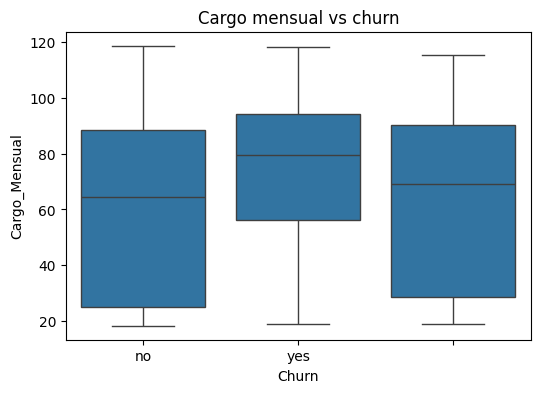

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="Cargo_Mensual", data=df)

plt.title("Cargo mensual vs churn")

plt.show()

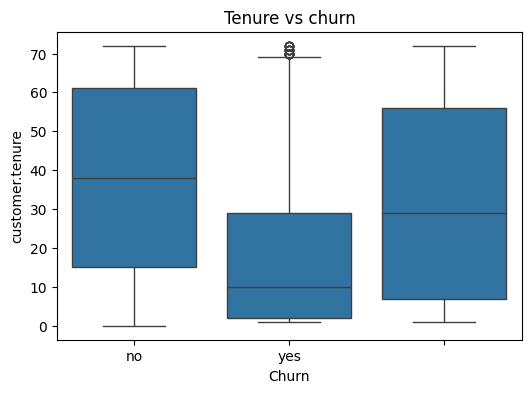

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tenure vs churn")

plt.show()